In [1]:
import pandas as pd

from src.data_loader import load_production_data, load_price_data
from src.preprocessing import clean_faostat, clean_prices
from src.aggregation import aggregate_prices_by_year
from src.merge_data import merge_datasets
from src.analysis import show_summary_statistics, show_correlation_matrix
from src.visualization import (
    plot_project_dashboard,
    plot_correlation_heatmap
)
from src.time_series_analysis import moving_average_analysis
from src.forecasting import run_linear_regression_models, plot_all_predictions
from src.arima_forecasting import run_arima_models, plot_arima_results
from src.random_forest_model import (
    run_random_forest_models,
    plot_random_forest_results
)
from src.feature_importance import (
    analyze_feature_importance,
    plot_all_feature_importance
)
from src.model_comparison import compare_models
from src.future_forecast import (
    forecast_prices_until_2030,
    plot_future_price_forecast
)
from src.save_results import (
    save_model_comparison,
    save_feature_importance
)
from src.feature_selection_experiment import (
    run_feature_selection_experiment
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:

print("Loading data...")

production_df = load_production_data()
price_df = load_price_data()

print("Cleaning data...")

production_df = clean_faostat(production_df)
print("\nFAOSTAT ITEMS AFTER CLEANING:")
print(production_df["item"].value_counts())
price_df = clean_prices(price_df)


Loading data...
Cleaning data...

FAOSTAT ITEMS AFTER CLEANING:
item
barley       25
buckwheat    25
maize        25
millet       25
oats         25
rice         25
rye          25
sorghum      25
wheat        25
Name: count, dtype: int64


In [3]:

print("Aggregating price data...")

price_df = aggregate_prices_by_year(price_df)

print("Merging datasets...")

final_df = merge_datasets(price_df, production_df)

final_df.to_csv(
    "data/processed/final_dataset.csv",
    index=False
)

Aggregating price data...
Merging datasets...



Final dataset saved to data/processed/final_dataset.csv

FINAL DATASET:
   year  oil_mean  oil_max  oil_min  wheat_mean  wheat_max  wheat_min  \
0  2000     28.23    32.33    23.47      114.09     128.18     105.11   
1  2001     24.35    27.55    18.52      126.81     134.86     121.92   
2  2002     24.93    28.28    19.15      148.08     190.32     121.46   
3  2003     28.90    32.88    25.56      146.14     165.57     131.35   
4  2004     37.73    46.88    31.33      156.88     166.58     141.29   

   maize_mean  maize_max  maize_min  barley_mean  barley_max  barley_min  \
0       88.53      97.56      75.27        77.23       86.60       73.13   
1       89.64      95.15      83.31        93.94      102.86       82.31   
2       99.27     114.14      87.13       108.97      120.99       95.82   
3      105.37     111.16      96.81       104.74      115.50       88.07   
4      111.80     133.50      93.75        98.99      114.05       85.37   

   sorghum_mean  sorghum_max  s

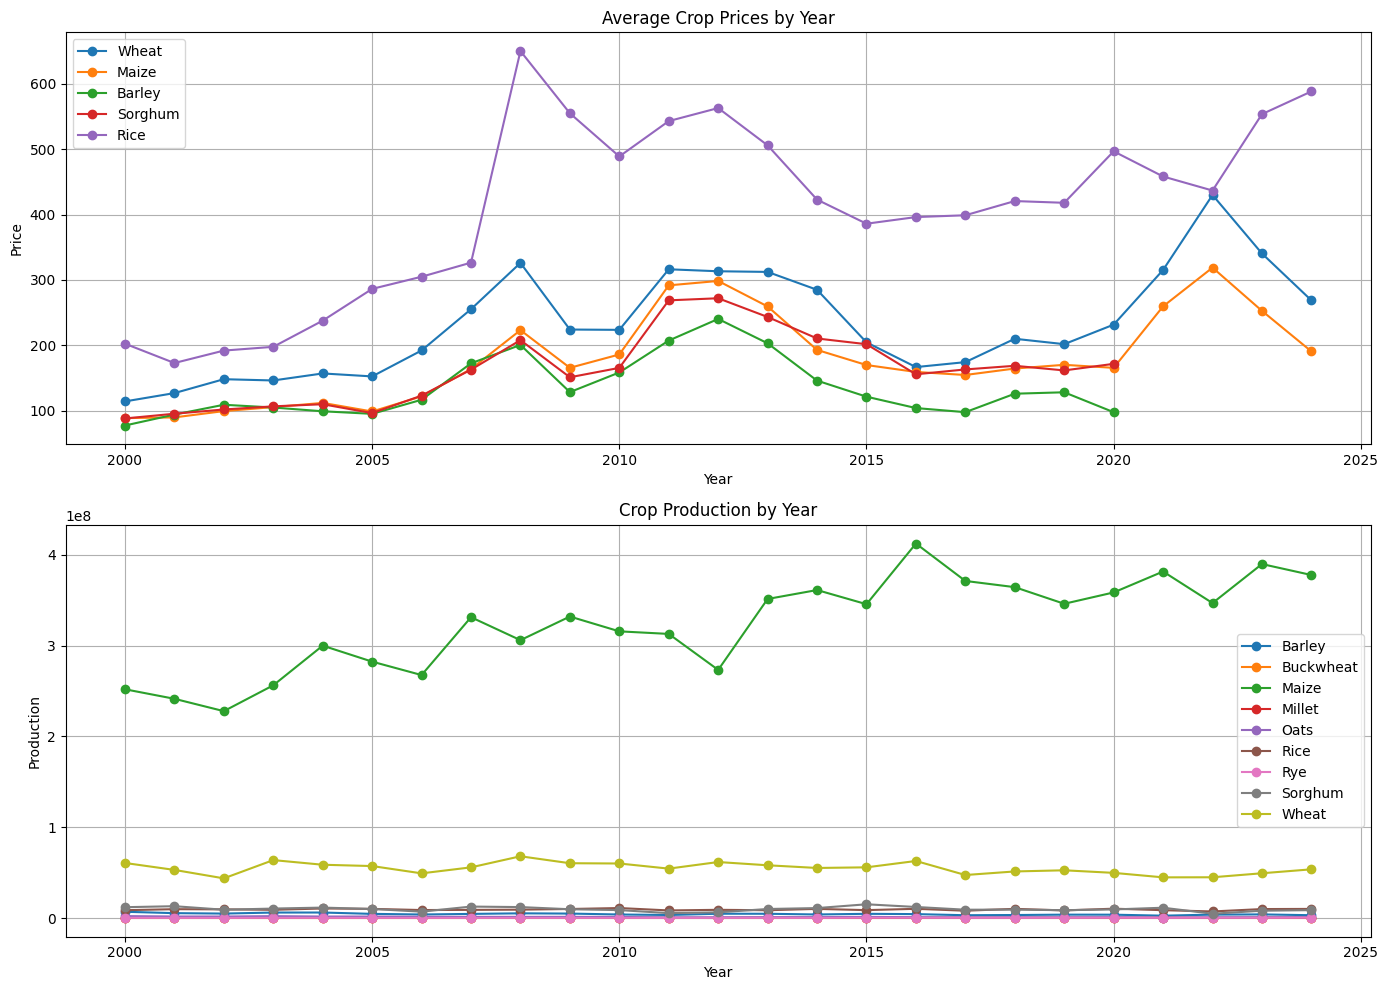

Saved: results/plots/correlation_heatmap.png


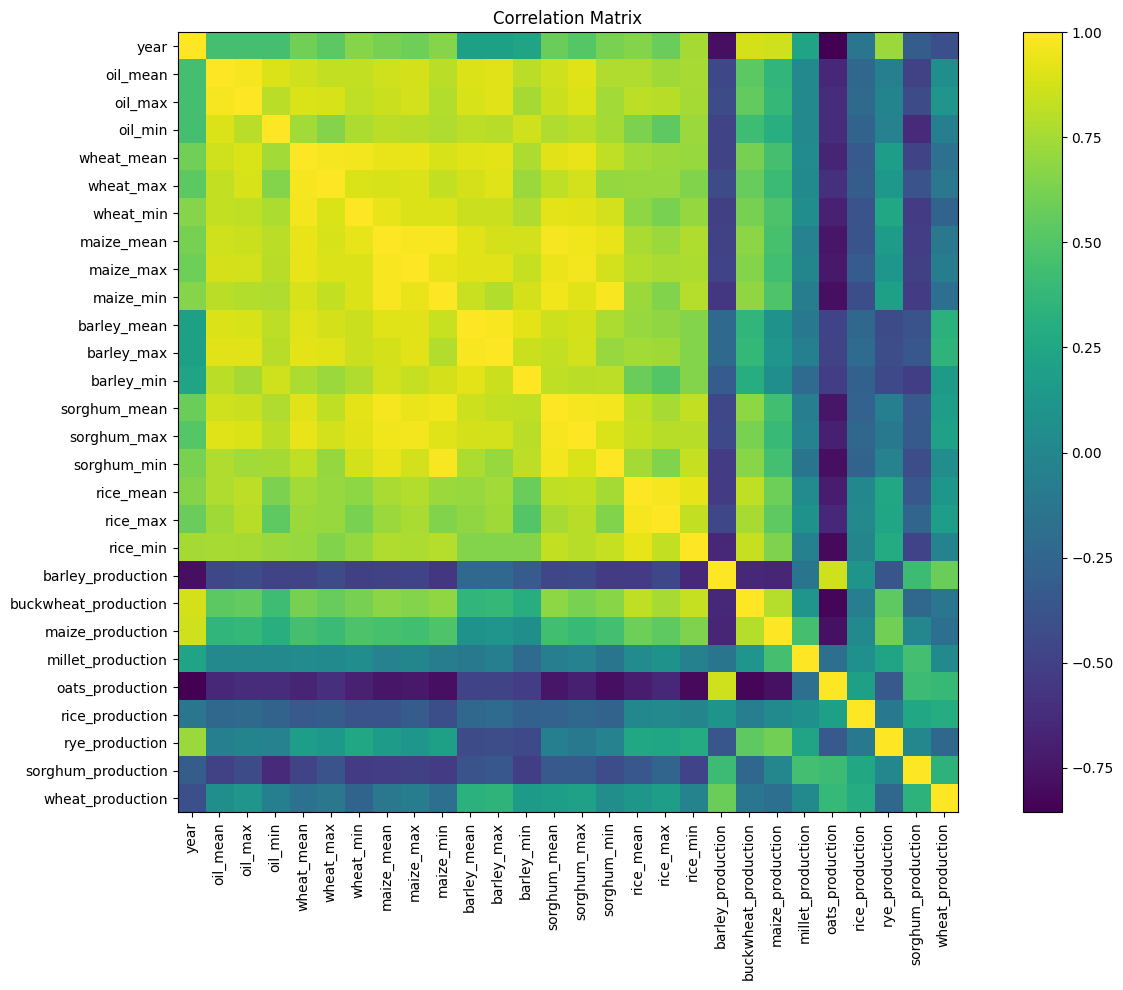

Saved: results/plots/moving_average.png


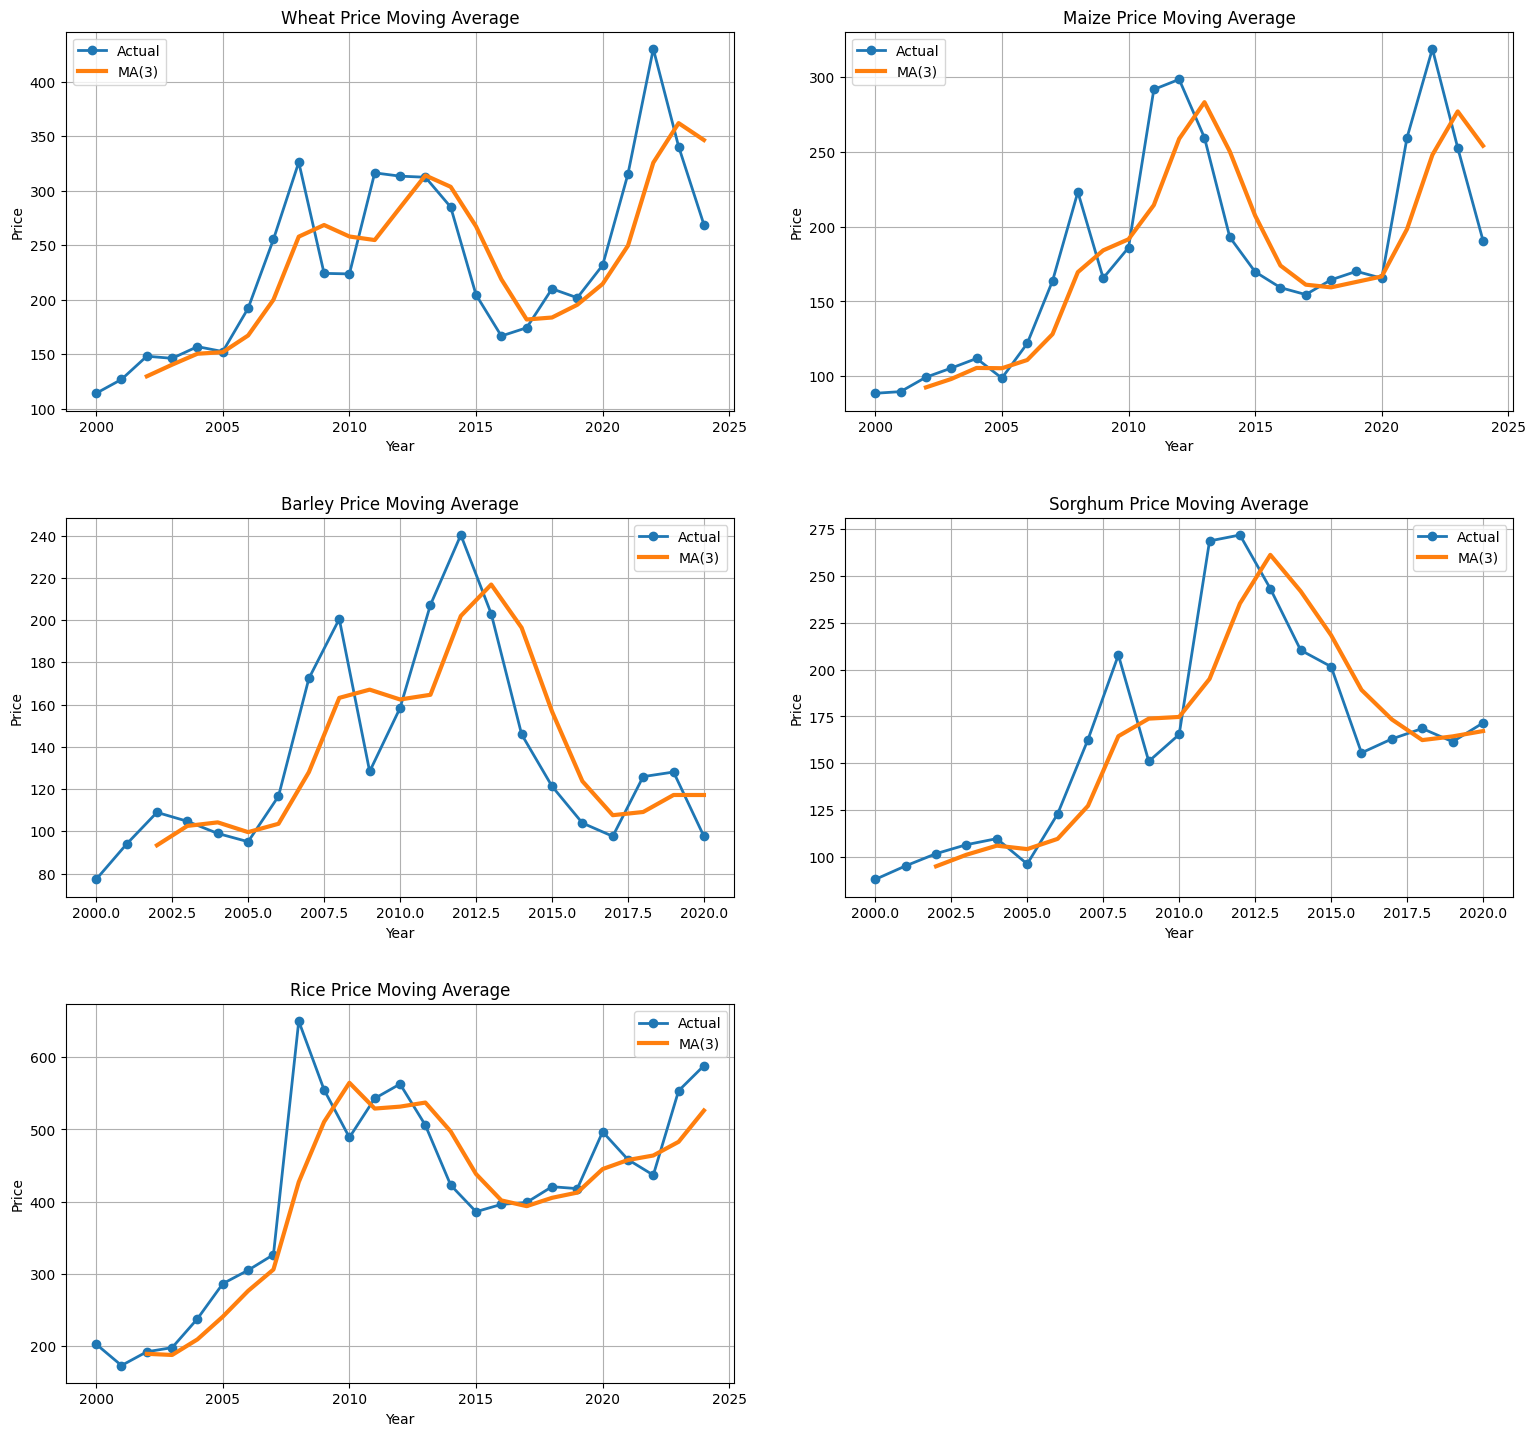

In [4]:
print("\nFinal dataset saved to data/processed/final_dataset.csv")

print("\nFINAL DATASET:")
print(final_df.head())

show_summary_statistics(final_df)
show_correlation_matrix(final_df)

plot_project_dashboard(final_df)
plot_correlation_heatmap(final_df)
moving_average_analysis(final_df)



LINEAR REGRESSION RESULTS FOR WHEAT
MAE: 16.18251285588475
RMSE: 19.73933832568018
R2: 0.18674815453627025

PREDICTIONS:
    year  actual_price  predicted_price
15  2015        204.45           211.31
16  2016        166.63           196.35
17  2017        174.20           206.65
18  2018        209.93           223.59
19  2019        201.69           214.54
20  2020        231.57           233.11

LINEAR REGRESSION RESULTS FOR MAIZE
MAE: 7.0429377560040125
RMSE: 7.311674009891106
R2: -0.7316151181697783

PREDICTIONS:
    year  actual_price  predicted_price
15  2015        169.75           180.19
16  2016        159.16           150.65
17  2017        154.53           148.27
18  2018        164.41           168.79
19  2019        170.07           164.34
20  2020        165.47           172.41

LINEAR REGRESSION RESULTS FOR BARLEY
MAE: 20.090337034036448
RMSE: 22.81430194268232
R2: -2.0738476398367203

PREDICTIONS:
    year  actual_price  predicted_price
15  2015        121.33         

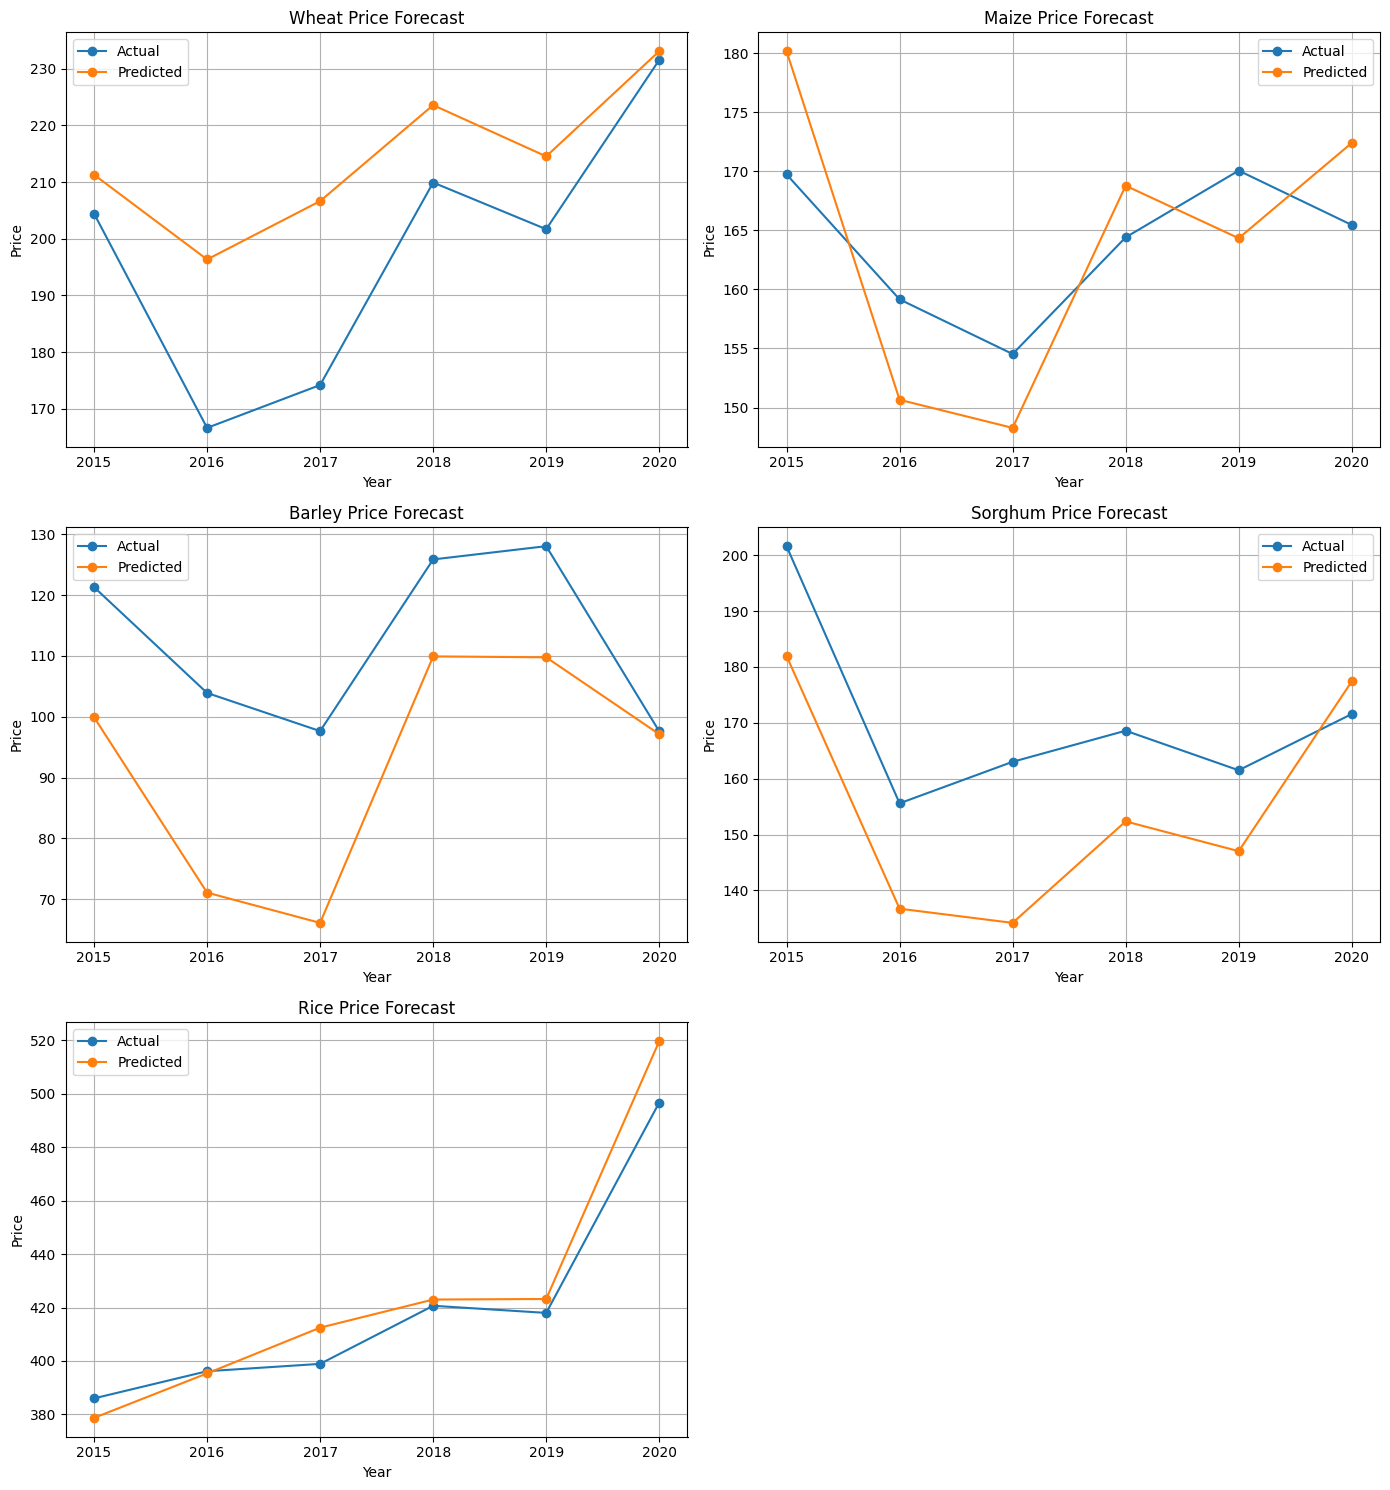


ARIMA MODEL COMPARISON:
      crop           model    MAE   RMSE
0    Wheat  ARIMA(0, 2, 1) 101.80 121.71
1    Maize  ARIMA(0, 2, 2)  58.98  77.58
2   Barley  ARIMA(2, 2, 2)  69.56  76.51
3  Sorghum  ARIMA(0, 2, 3) 113.50 114.84
4     Rice  ARIMA(0, 2, 1)  60.76  72.21
Saved: results/plots/arima_forecasts.png


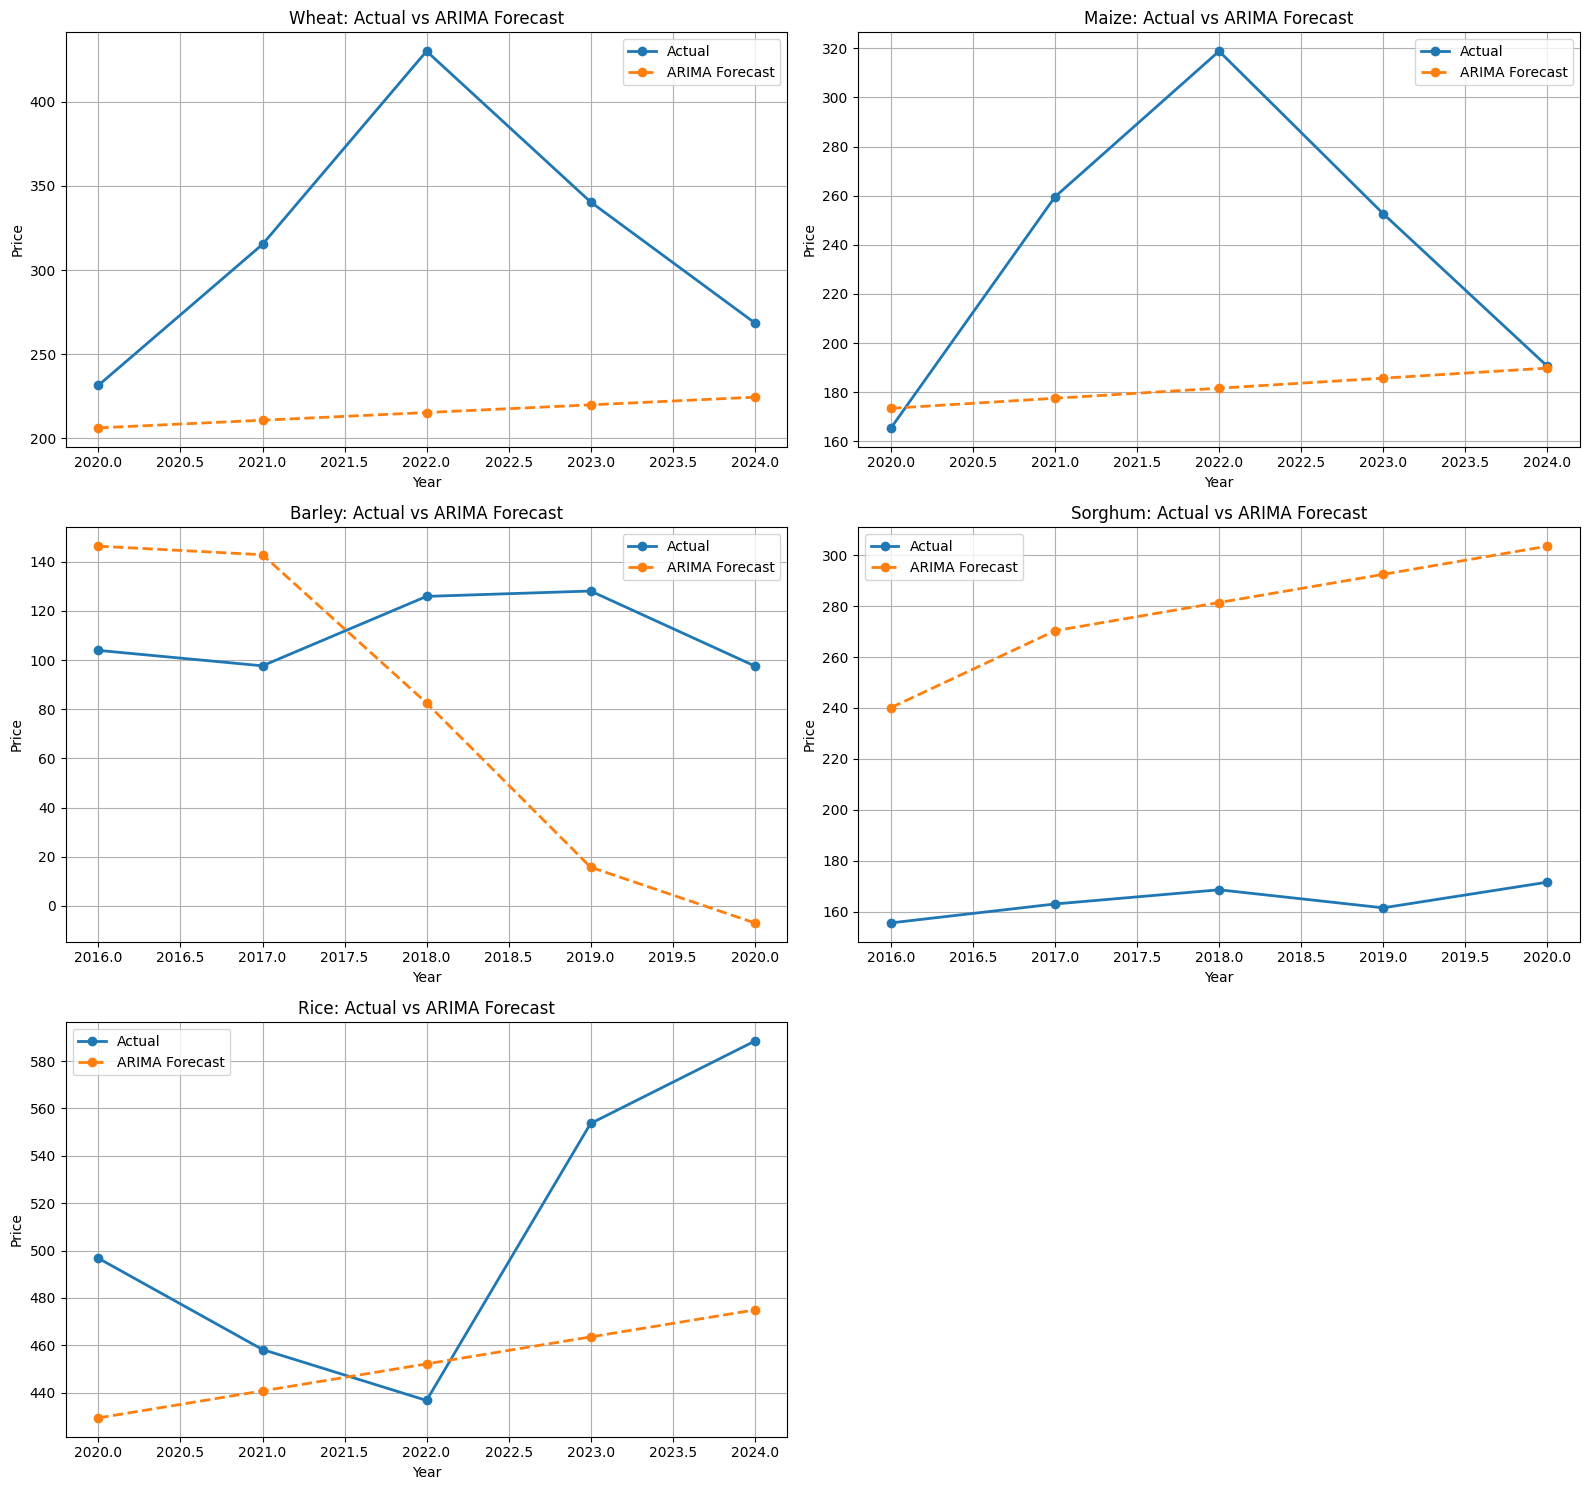


RANDOM FOREST RESULTS FOR WHEAT
MAE: 28.533737997896708
RMSE: 31.48472693479158
R2: -1.0689964143733208

RANDOM FOREST RESULTS FOR MAIZE
MAE: 6.721718813500449
RMSE: 8.010314913761494
R2: -1.0783414951134818

RANDOM FOREST RESULTS FOR BARLEY
MAE: 29.71500283374252
RMSE: 31.294737204861914
R2: -4.783764283019292

RANDOM FOREST RESULTS FOR SORGHUM
MAE: 11.006394874361945
RMSE: 17.68588593297229
R2: -0.4081112745440081

RANDOM FOREST RESULTS FOR RICE
MAE: 26.483135648148117
RMSE: 34.70185451141367
R2: 0.1037260758930808

RANDOM FOREST MODEL COMPARISON:
      crop          model   MAE  RMSE    R2
0    Wheat  Random Forest 28.53 31.48 -1.07
1    Maize  Random Forest  6.72  8.01 -1.08
2   Barley  Random Forest 29.72 31.29 -4.78
3  Sorghum  Random Forest 11.01 17.69 -0.41
4     Rice  Random Forest 26.48 34.70  0.10

FULL MODEL COMPARISON
       crop              model    MAE   RMSE    R2
0     Wheat  Linear Regression  16.18  19.74  0.19
1     Maize  Linear Regression   7.04   7.31 -0.73
2  

In [5]:
forecast_results = run_linear_regression_models(final_df)
forecast_metrics = forecast_results["metrics"]
plot_all_predictions(forecast_results)

arima_results, arima_metrics = run_arima_models(final_df)
plot_arima_results(arima_results)

rf_results, rf_metrics = run_random_forest_models(
    final_df
)

comparison_df = compare_models(
    forecast_metrics,
    arima_metrics,
    rf_metrics
)



Saved: results/model_comparison.csv
Saved: results/plots/random_forest_forecasts.png


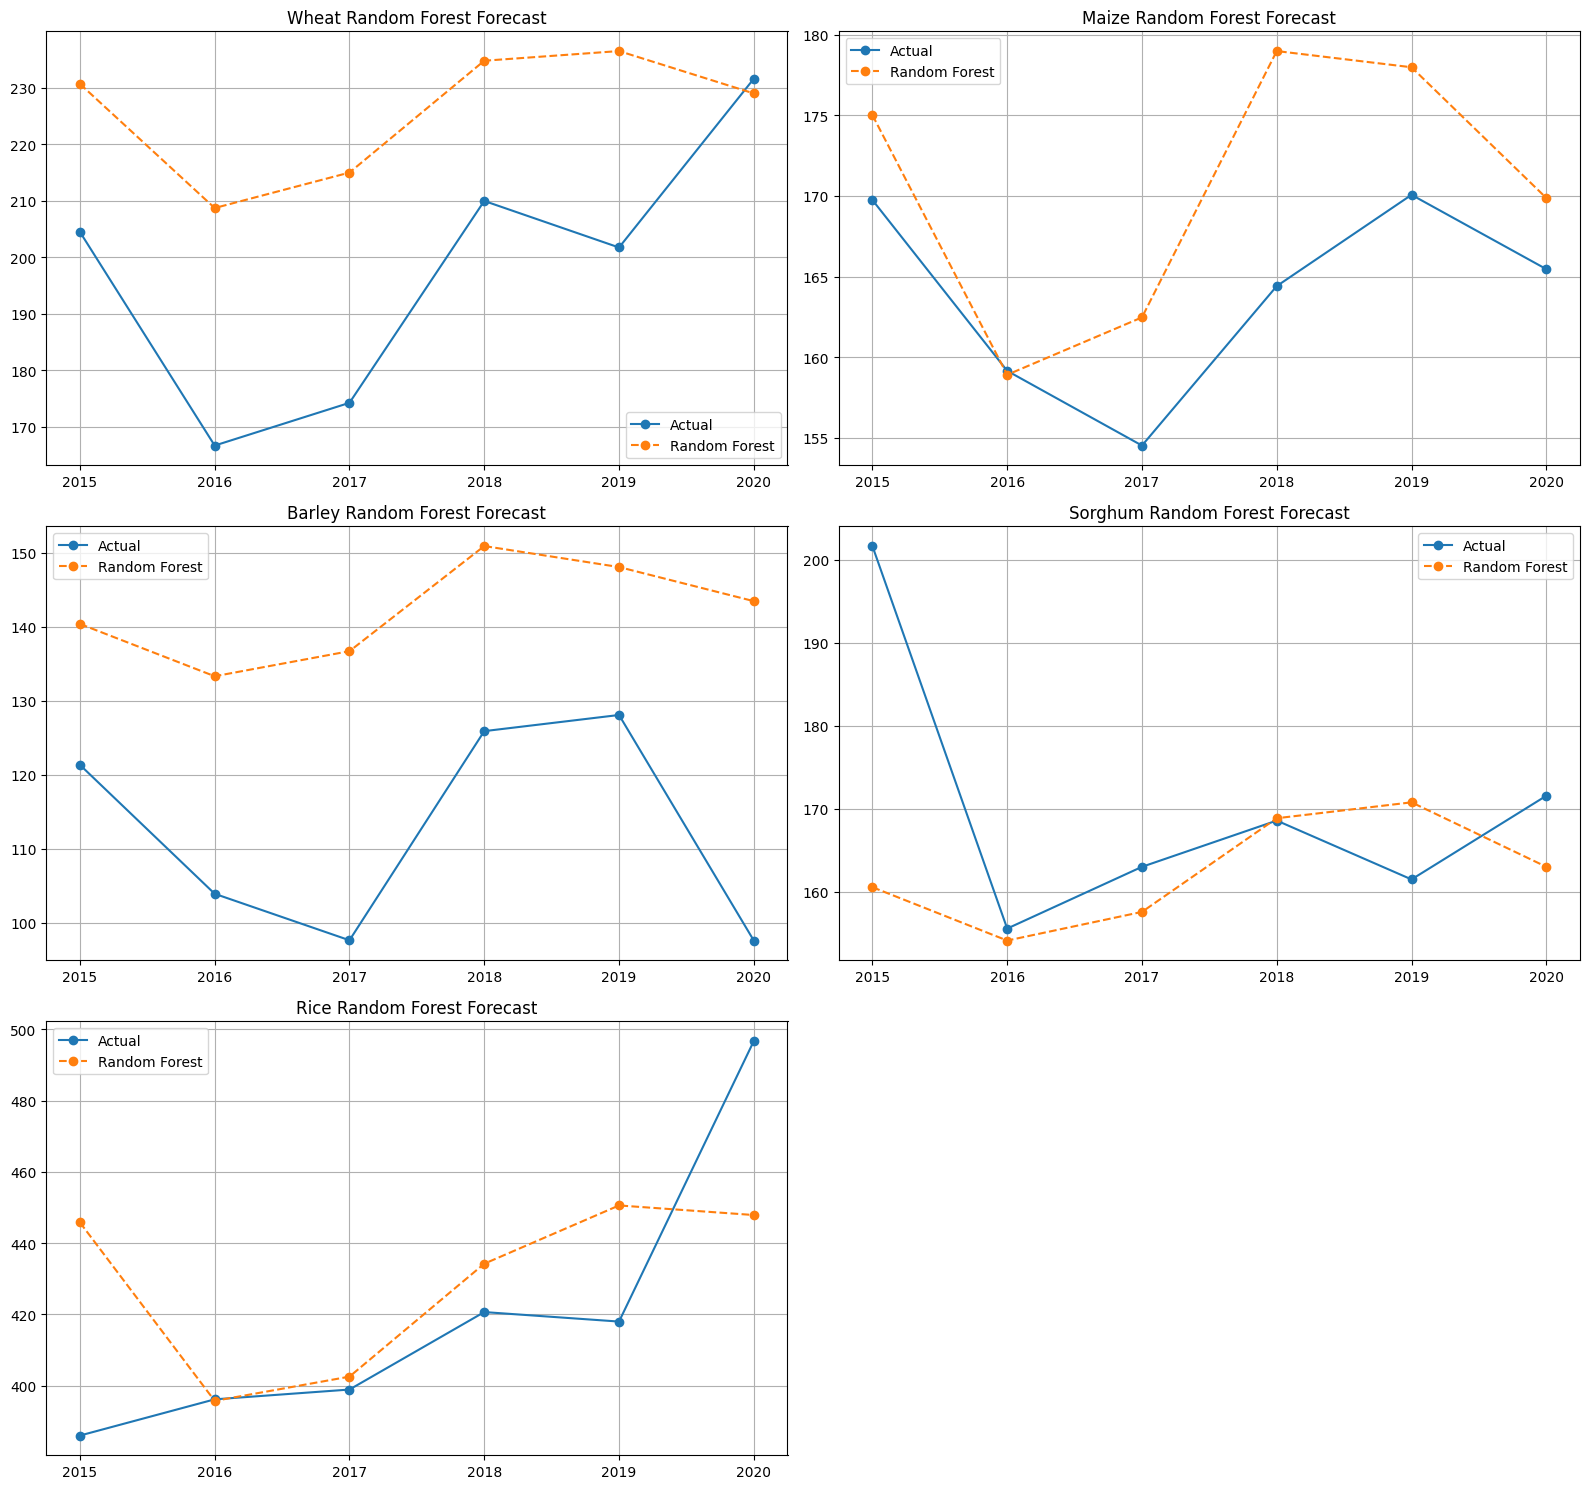

In [6]:
save_model_comparison(
    comparison_df
)

plot_random_forest_results(
    rf_results
)


FEATURE IMPORTANCE FOR WHEAT
                 feature  importance
2            barley_mean        0.28
0               oil_mean        0.23
1             maize_mean        0.22
3           sorghum_mean        0.13
4              rice_mean        0.05
9        oats_production        0.02
5      barley_production        0.02
7       maize_production        0.01
12    sorghum_production        0.01
6   buckwheat_production        0.01
10       rice_production        0.01
8      millet_production        0.00
11        rye_production        0.00
13      wheat_production        0.00
Saved: feature_importance_wheat.csv

FEATURE IMPORTANCE FOR MAIZE
                 feature  importance
2            barley_mean        0.18
1             wheat_mean        0.17
0               oil_mean        0.16
3           sorghum_mean        0.13
4              rice_mean        0.12
9        oats_production        0.07
7       maize_production        0.06
6   buckwheat_production        0.04
12    sorghum_pr

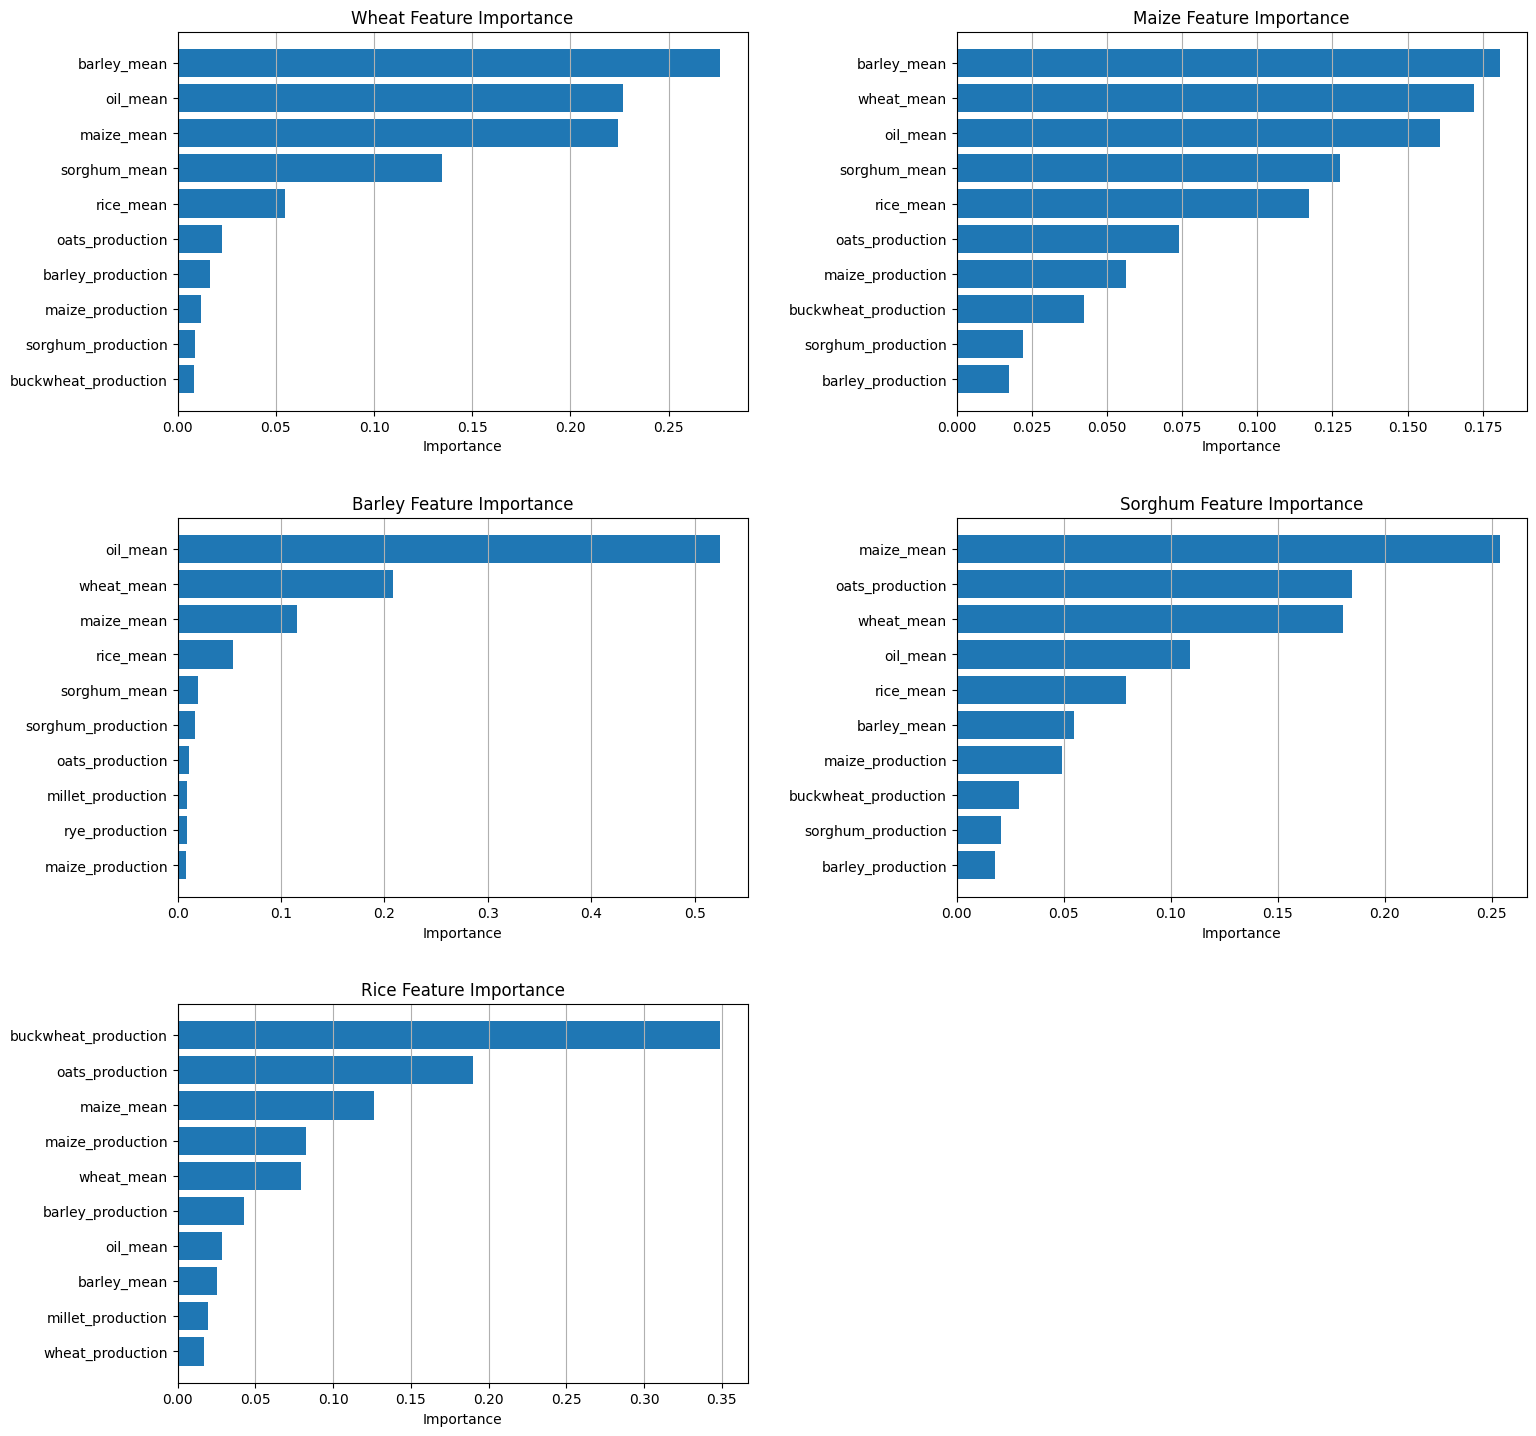

In [7]:
crops_for_importance = {
    "Wheat": "wheat_mean",
    "Maize": "maize_mean",
    "Barley": "barley_mean",
    "Sorghum": "sorghum_mean",
    "Rice": "rice_mean"
}


importance_results = {}

for crop_name, target_column in crops_for_importance.items():
    if target_column in final_df.columns:

        importance_df = analyze_feature_importance(
            final_df,
            target_column,
            crop_name
        )

        save_feature_importance(
            importance_df,
            crop_name
        )

        importance_results[crop_name] = importance_df

plot_all_feature_importance(importance_results)



FORECAST PRICES UNTIL 2030:
   year  Wheat  Maize  Barley  Sorghum   Rice
0  2025 292.53 228.32  183.71   227.72 519.96
1  2026 294.06 228.48  185.79   229.93 525.92
2  2027 294.05 233.44  187.35   234.24 526.04
3  2028 294.55 233.53  187.73   234.88 525.52
4  2029 295.01 234.27  193.63   237.81 532.57
5  2030 296.50 237.77  194.52   238.80 533.86


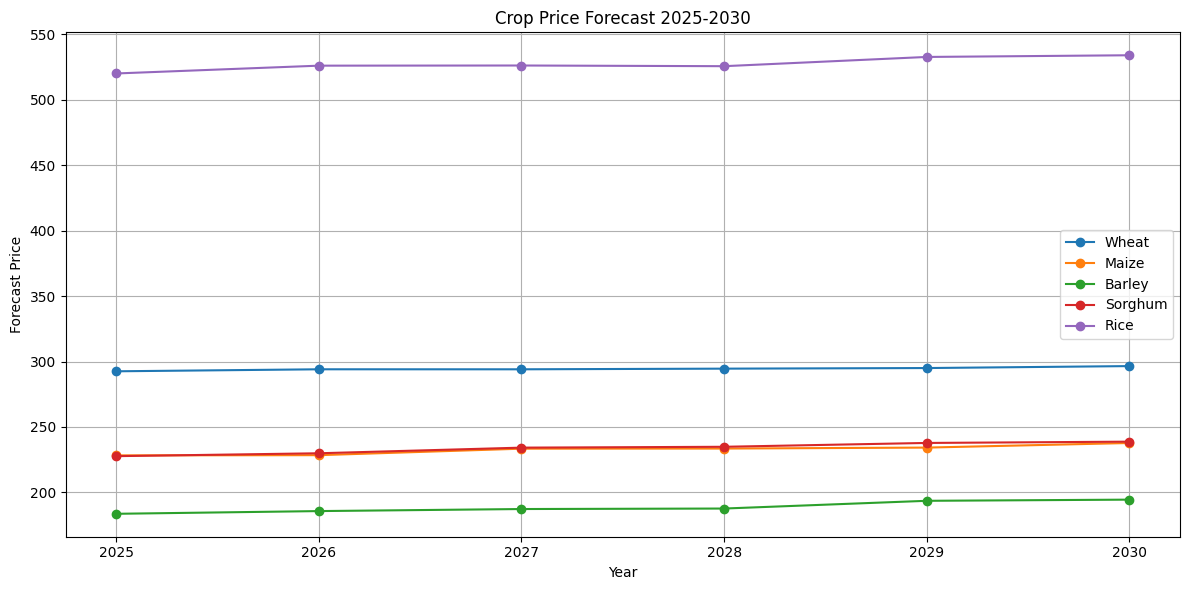


FEATURE SELECTION EXPERIMENT
      crop    MAE   RMSE     R2
0    Wheat  26.85  32.64  -1.22
1    Maize  12.64  17.64  -9.08
2   Barley  17.06  23.00  -2.12
3  Sorghum  13.90  18.15  -0.48
4     Rice 133.04 163.81 -18.97


,crop,MAE,RMSE,R2
0,Wheat,26.85,32.64,-1.22
1,Maize,12.64,17.64,-9.08
2,Barley,17.06,23.00,-2.12
3,Sorghum,13.90,18.15,-0.48
4,Rice,133.04,163.81,-18.97


In [8]:
future_forecast = forecast_prices_until_2030(final_df)

plot_future_price_forecast(future_forecast)

run_feature_selection_experiment(
    final_df
)
